In [24]:
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar
# import the PDE solver for 2D advection-diffusion problem
import adv_dif_2D_bott
import adv_dif_2D_bott_Nflux

In [25]:
# set parameters
Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x+4)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
U = 0 # 0 for constant wind / 1 for y-dependent wind 
N_flux = 0.01 # only for adv_dif_2D_Nflux (default=0.01 per time)

In [26]:
# load and use the PDE solver
importlib.reload(adv_dif_2D_bott)
importlib.reload(adv_dif_2D_bott_Nflux)

c=adv_dif_2D_bott.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U])
#c=adv_dif_2D_bott_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])

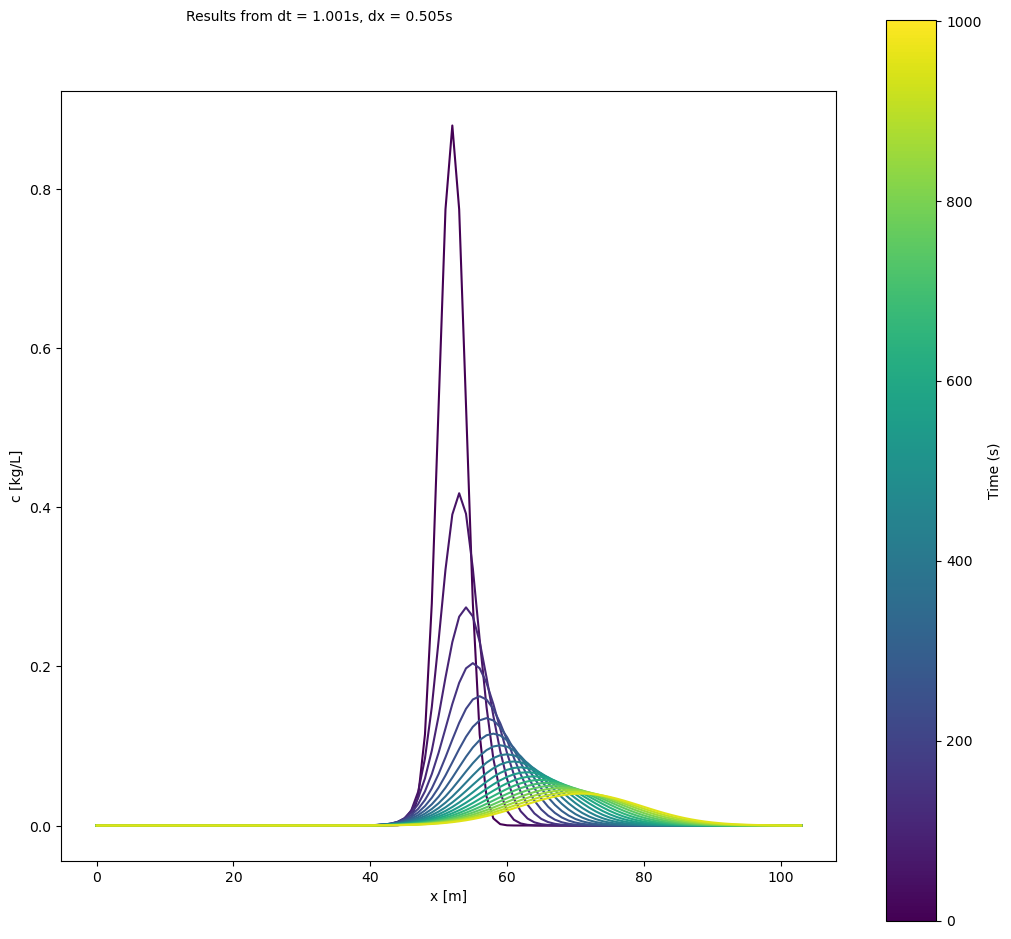

In [27]:
fig, ax_c = plt.subplots(1,1, figsize=(10,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fs' % (dt, dx))
ax_c.set_ylabel('c [kg/L]')
ax_c.set_xlabel('x [m]')

# We use color to differentiate lines at different times.  Set up the color map
cmap = plt.get_cmap('viridis')
cNorm  = colors.Normalize(vmin=0, vmax=1.*n_time)
cNorm_inseconds = colors.Normalize(vmin=0, vmax=1.*(n_time-1)*dt)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

# Only try to plot 20 lines, so choose an interval if more than that (i.e. plot every interval lines)
interval = int(np.ceil(n_time/20))

# Do the main plot
for time in range(0, n_time, interval):
    colorVal = scalarMap.to_rgba(time)
    ax_c.plot(c[time,:,0], color=colorVal)

# Add the custom colorbar
ax_c = fig.add_axes([0.95, 0.05, 0.05, 0.9])
cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)
cb1.set_label('Time (s)')

(104, 100)
(104, 100)


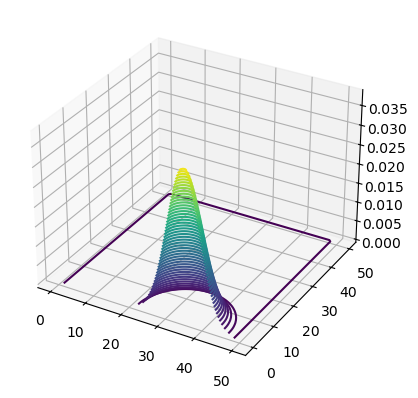

In [28]:
Y, X = np.meshgrid(y, x)
print(np.shape(X))
print(np.shape(Y))

# Creating a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the 3D contour
#ax.contour3D(X, Y, c[0,:,:], 50, cmap='viridis')
#ax.contour3D(X, Y, c[300,:,:], 50, cmap='viridis')
#ax.contour3D(X, Y, c[600,:,:], 50, cmap='viridis')
ax.contour3D(X, Y, c[999,:,:], 50, cmap='viridis')

0.0 0.8802599597515598


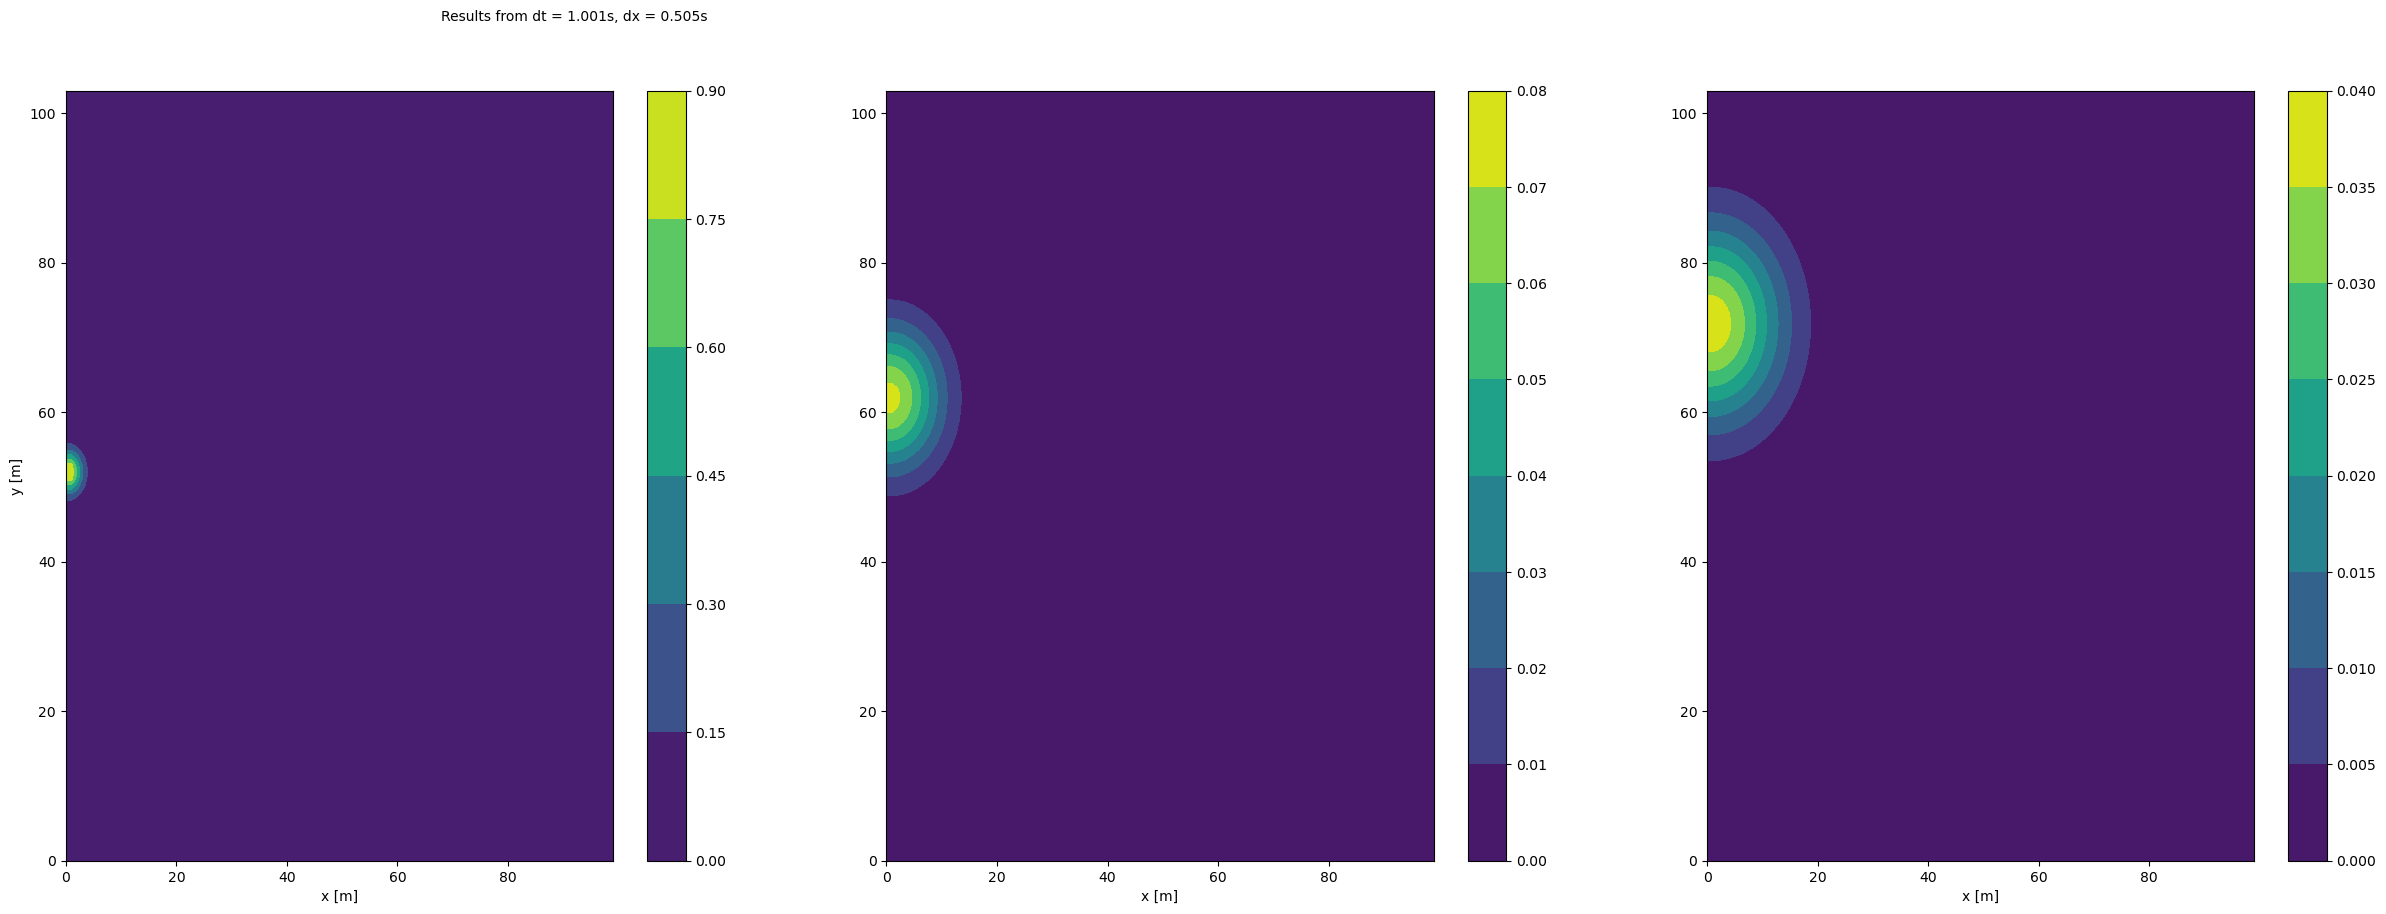

In [29]:
from matplotlib import cm, colors
fig, ax_c = plt.subplots(1,3, figsize=(30,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fs' % (dt, dx))
ax_c[0].set_ylabel('y [m]')
ax_c[0].set_xlabel('x [m]')
ax_c[1].set_xlabel('x [m]')
ax_c[2].set_xlabel('x [m]')

minval = np.min(c[0,:,:])
maxval = np.max(c[0,:,:])
print(minval,maxval)
cf0 = ax_c[0].contourf(c[0,:,:])#,norm=colors.LogNorm(vmin=0.01, vmax=maxval))
cf1 = ax_c[1].contourf(c[500,:,:])#,norm=colors.LogNorm(vmin=0.01, vmax=maxval))
cf2 = ax_c[2].contourf(c[999,:,:])#,norm=colors.LogNorm(vmin=0.01, vmax=maxval))
cbar = fig.colorbar(cf0, ax=ax_c[0])
cbar = fig.colorbar(cf1, ax=ax_c[1])
cbar = fig.colorbar(cf2, ax=ax_c[2])
#cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)